In [37]:
class Employee():
   
    raise_amt = 1.04

    def __init__(self, first, last, pay):
        self.first = first; self.last = last; self.pay = pay
        self.email = first+"_"+last+"@gmail.com"
    
    def fullname(self):
        return "{} {}".format(self.first, self.last)
    
    def apply_raise(self):
        self.pay = int(self.raise_amt * self.pay)

class Developer(Employee):
    raise_amt = 1.2
    def __init__(self, first, last, pay): 
        super().__init__(first, last, pay)
        self.projects_working = []

    def add_to_project(self, name):
        self.projects_working.append(name)


dev1 = Developer("Burak","Elitok", 1000)
emp1 = Employee("Ahmet","Demirlek",1000)


In [1]:
dev1.apply_raise()
emp1.apply_raise()

NameError: name 'dev1' is not defined

In [40]:
print(dev1.pay, emp1.pay)

1200 1040


In [25]:
help(Developer)

Help on class Developer in module __main__:

class Developer(Employee)
 |  Developer(first, last, pay)
 |
 |  Method resolution order:
 |      Developer
 |      Employee
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, first, last, pay)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  add_to_project(self, name)
 |
 |  ----------------------------------------------------------------------
 |  Methods inherited from Employee:
 |
 |  apply_raise(self)
 |
 |  fullname(self)
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from Employee:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object
 |
 |  ----------------------------------------------------------------------
 |  Data and other attributes inherited from Employee:
 |
 |  raise_amt = 1.04



In [15]:
import datetime as dt

class LibraryItem: 
    def __init__(self, title, item_id):
        self.title = title
        self.item_id = item_id
        self.available = True #Upon initiating, availability is True

    def check_out(self):
        if self.available == True:
            self.available = False
        print("Item: {} borrowed".format(self.title))

    def return_item(self):
        if self.available == False:
            self.available = True
        print("Item: {} returned".format(self.title))

    def get_info(self):
        pass

class Book(LibraryItem):
    def __init__(self, title, item_id, author, pages):
        super().__init__(title, item_id)
        self.author = author 
        self.pages = pages
    def get_info():
        pass

class DVD(LibraryItem):
    def __init__(self, title, item_id, director, runtime):
        super().__init__(title, item_id)
        self.director = director 
        self.runtime = runtime
    def get_info():
        pass

class Member:
    def __init__(self, name, member_id):
        self.name = name
        self.member_id = member_id
        self.borrowed_items = []
        self.loans = {}

    def borrow_item(self, item: LibraryItem):
        due = dt.date.today() + dt.timedelta(days=7)
        loan = Loan(item, self, due)
        self.loans[item.title] = loan
        self.borrowed_items.append(item)
        item.check_out()
        print("User: {} Borrowed Item: {}\n Due Date: {}".format(self.name, item.title, str(due)))
        return loan

    def return_item(self, item: LibraryItem):
        del self.loans[item.name]
        self.borrowed_items.remove(item)
        item.return_item()
        print("User: {} Borrowed Item: {}")


    def list_borrowed(self):
        return self.borrowed_items

class Loan: 
    """
    A class of loan to show transactions,
    particularly relationship between members and items. 
    Representing relationship between an item and a member. 
    """
    def __init__(self, item, member, due_date):
        self.item = item
        self.member = member
        self.due_date = due_date
    def __del__(self):
        print("Loan Removed.")
        
    def is_overdue(self):
        if dt.date.today() > self.due_date:
            self.overdue = 1 
            print("Item Overdue!")
        else:
            print("No worries, you got untill: {}".format(str(self.due_date)))


In [16]:
sevket = Member("Sevket", "31")
crypto = Book("How to Get Rich with Crypto", "31234", "Saxo Pristen", "631")
sevket.borrow_item(crypto)


Item: How to Get Rich with Crypto borrowed
User: Sevket Borrowed Item: How to Get Rich with Crypto
 Due Date: 2026-04-15


In [24]:
sevket.borrowed_items[0].available

False

In [ ]:
sevket.return_item(crypto)

#### Ek
Derste yapılmis bazi orneklerin tekrari

In [47]:
###Monte Carlo Sim
import random

class Sampler:
    def sample(self):
        """returns x, y"""
        return random.random(), random.random() 
    #honestly, no need to define a class for this but whatever

class MonteCarlo:
    def __init__(self):
        """For modelling dots inside and outside a circle"""
        self.inside = 0
        self.total = 0
    def estimate_pi(self, sampler): #honestly, i have no idea why dont we do this differently
        x, y = sampler.sample()
        if (x**2) + (y**2) <= 1: 
            self.inside += 1
        self.total += 1 
        return 4 * self.inside / self.total
           

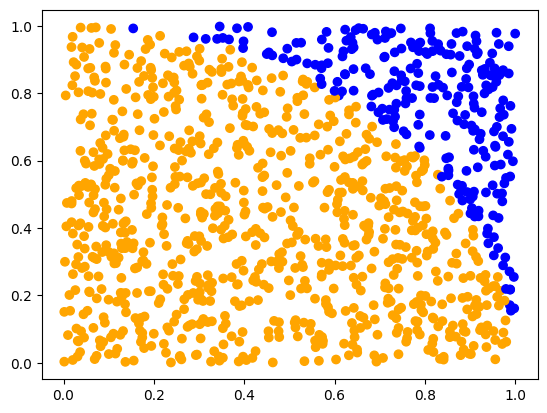

In [60]:
import matplotlib.pyplot as plt

sampler = Sampler()
mcsim = MonteCarlo()
xvals = []
yvals = []
tagger = []
for _ in range(1090):
    x , y = sampler.sample()
    xvals.append(x)
    yvals.append(y)
    if (x**2) + (y**2) <= 1:
        tagger.append("orange")
    else: 
        tagger.append("blue")

#inside-outside
plt.scatter(x = xvals, y = yvals, c = tagger)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import random

# Simple Walker Logic
class RandomWalk:
    def __init__(self, step_size = 1):
        self.step_size = step_size
    def step(self):
        return random.choice([-self.step_size, self.step_size])

class Walker:
    def __init__(self):
        self.positiony = 0
        self.positionx = 0
    def move(self, walk):
        self.positionx += walk.step()
        self.positiony += walk.step()
        return self.positionx, self.positiony
    def pos_reset(self):
        self.positiony = 0
        self.positionx = 0
    @staticmethod
    def sample_walkers(walker, walk, n_walkers, n_steps):              
        finalx_pos = []
        finaly_pos = []
        walk = RandomWalk()
        for walkers in range(n_walkers):
            walker = Walker()
            for steps in range(n_steps):
                walker.move(walk)
            finalx_pos.append(walker.positionx)
            finaly_pos.append(walker.positiony)
        return finalx_pos, finaly_pos
    


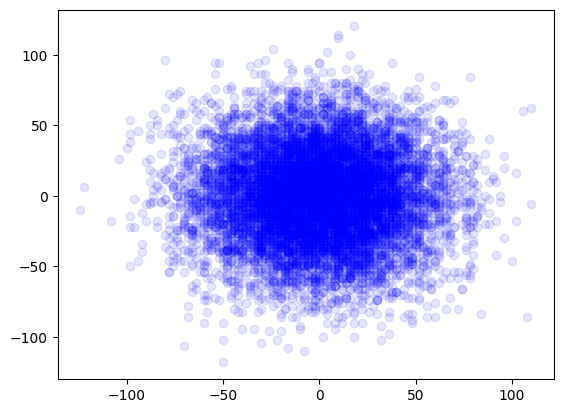

In [ ]:
walker = Walker()
step = RandomWalk()
x, y = walker.sample_walkers(walker, step, 10000, 1000)

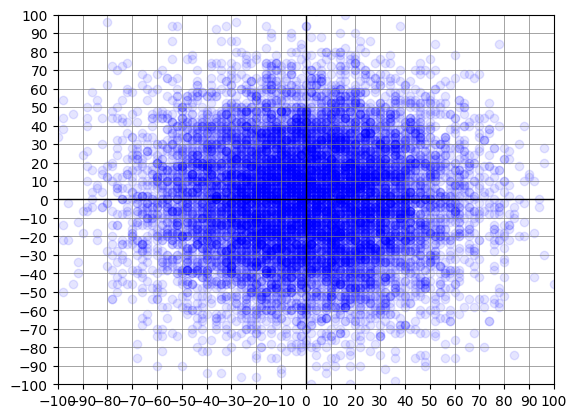

In [84]:
import numpy as np

fig, ax = plt.subplots()

# Set grid lines: both major and minor
ax.grid(True, which='both', linestyle='-', linewidth=0.5, color='gray')

# Optional: make the axis lines thicker
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

# Set tick intervals (e.g., 1 unit between lines)
ax.set_xticks(np.arange(-100, 110, 10))
ax.set_yticks(np.arange(-100, 110, 10))

# Set limits
ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)

plt.scatter(x, y, alpha=0.1, c = "blue")
plt.show()